# 🍷 Wine Quality Prediction
### Oasis Infobyte Internship — Data Analytics | Level 2, Task 2
**Name:** Param Parag Koli
**Batch:** July 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📂 Step 1 — Load Dataset & Initial Inspection

In [2]:
df = pd.read_csv('/content/winequality-red.csv')

print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nNull Values:\n", df.isnull().sum())
print("\nClass Distribution:\n", df['quality'].value_counts())
df.head(10)

Shape: (1599, 12)

Column Names: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Data Types:
 fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Null Values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Class Distribution:
 quality
5 

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


## 📊 Step 2 — EDA & Distribution Plots

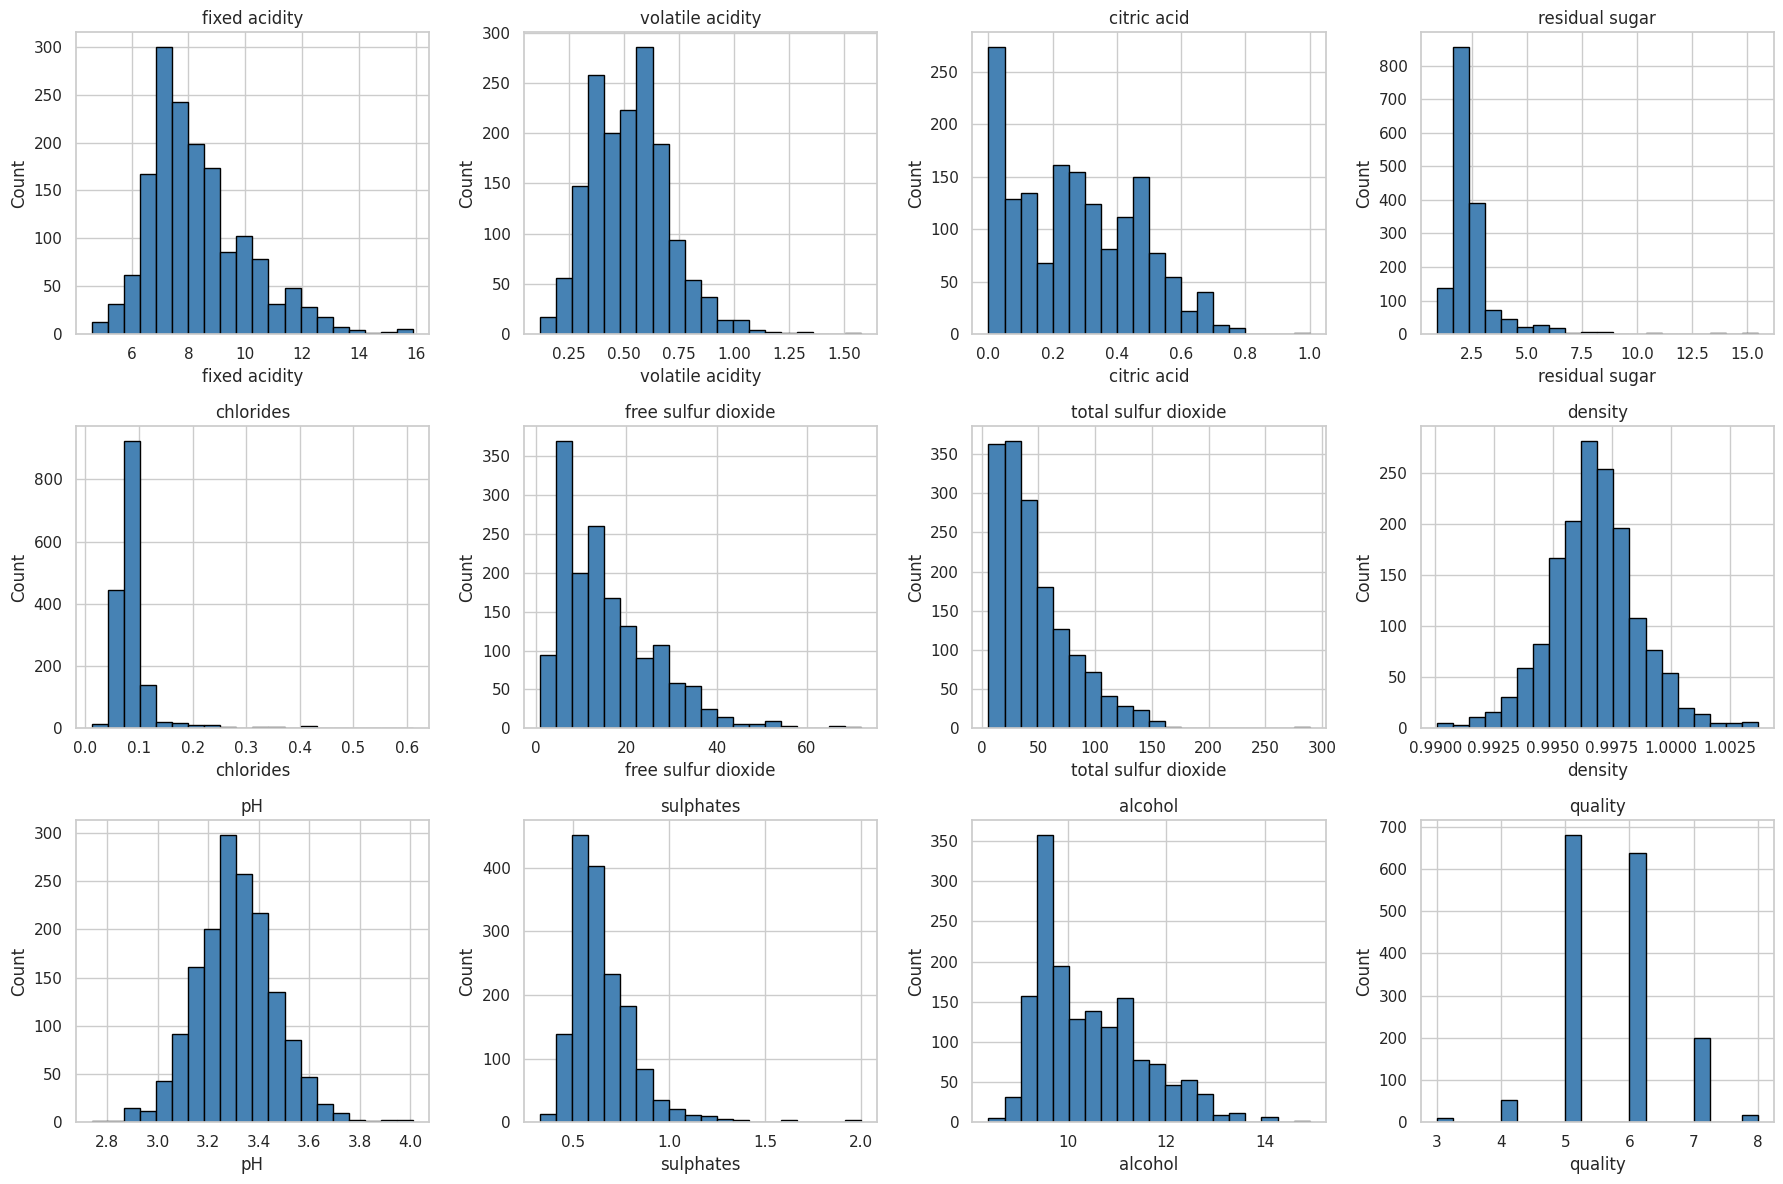

In [3]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 🔥 Step 3 — Correlation Heatmap

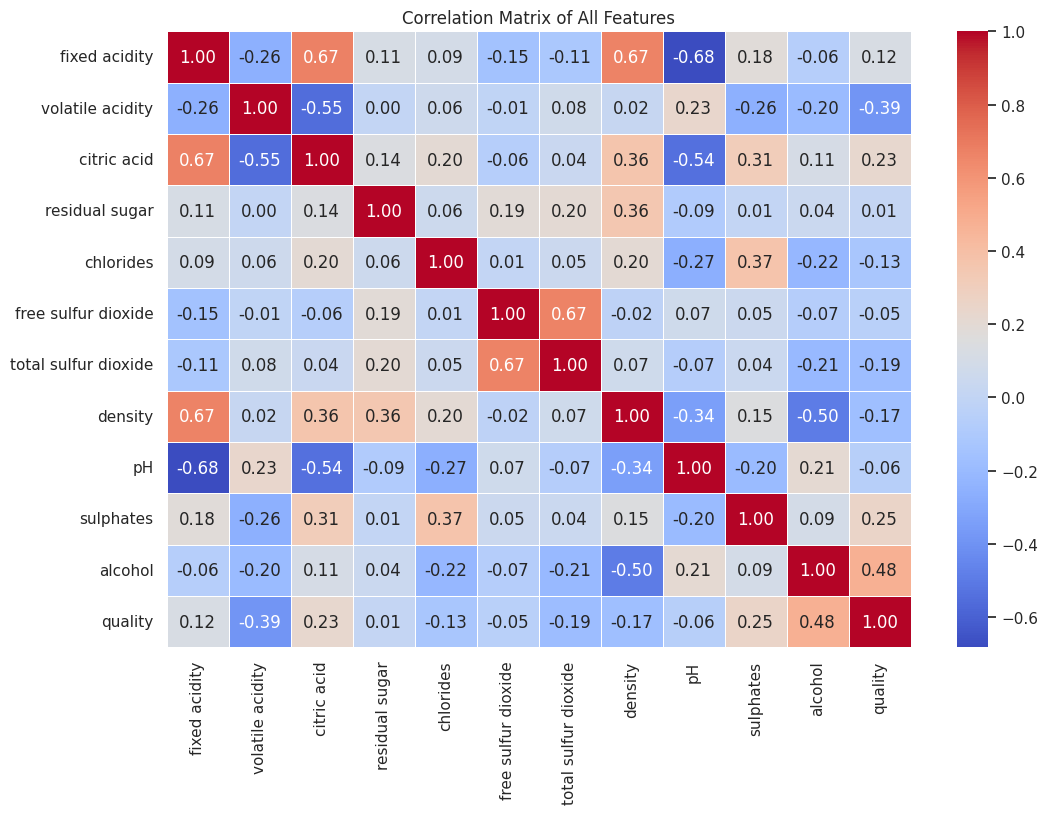

In [4]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of All Features')
plt.show()

## ⚖️ Step 4 — Class Imbalance Discussion & Feature Engineering

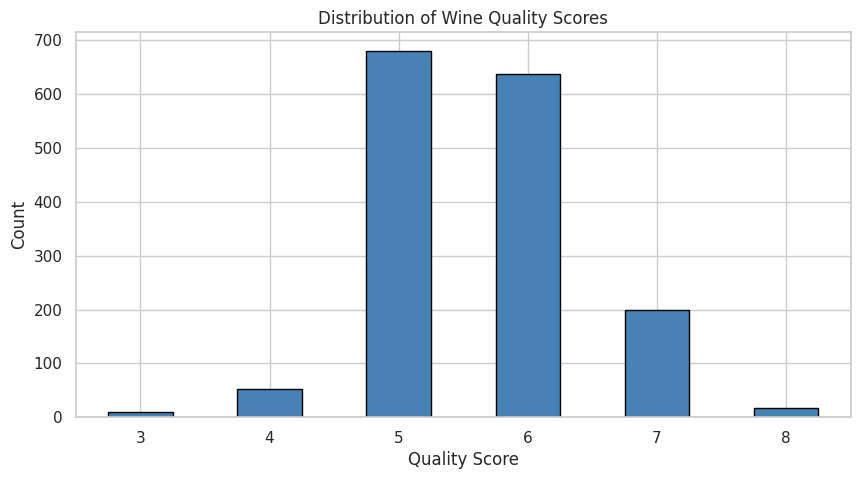


Binned Class Distribution:
 quality_label
low       744
medium    638
high      217
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(10, 5))
df['quality'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

df['quality_label'] = df['quality'].apply(lambda x: 'low' if x <= 5 else ('medium' if x == 6 else 'high'))

print("\nBinned Class Distribution:\n", df['quality_label'].value_counts())

## ✂️ Step 5 — Train/Test Split with Stratification

In [6]:
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nClass Distribution in Training Set:\n", pd.Series(y_train).value_counts())

Training set size: (1279, 11)
Testing set size: (320, 11)

Class Distribution in Training Set:
 quality_label
low       595
medium    510
high      174
Name: count, dtype: int64


## 🤖 Step 6 — Train Random Forest Classifier

In [7]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Results:")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

Random Forest Results:
Accuracy: 0.75

Classification Report:
               precision    recall  f1-score   support

        high       0.69      0.58      0.63        43
         low       0.80      0.83      0.82       149
      medium       0.71      0.71      0.71       128

    accuracy                           0.75       320
   macro avg       0.73      0.71      0.72       320
weighted avg       0.75      0.75      0.75       320



## 🤖 Step 7 — Train SGD Classifier

In [8]:
sgd_model = SGDClassifier(random_state=42, max_iter=1000)
sgd_model.fit(X_train, y_train)
sgd_pred = sgd_model.predict(X_test)

print("SGD Classifier Results:")
print("Accuracy:", round(accuracy_score(y_test, sgd_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, sgd_pred))

SGD Classifier Results:
Accuracy: 0.5687

Classification Report:
               precision    recall  f1-score   support

        high       0.50      0.09      0.16        43
         low       0.62      0.81      0.70       149
      medium       0.49      0.45      0.47       128

    accuracy                           0.57       320
   macro avg       0.54      0.45      0.44       320
weighted avg       0.55      0.57      0.53       320



## 🤖 Step 8 — Train Support Vector Classifier

In [9]:
svc_model = SVC(kernel='rbf', random_state=42)
svc_model.fit(X_train, y_train)
svc_pred = svc_model.predict(X_test)

print("Support Vector Classifier Results:")
print("Accuracy:", round(accuracy_score(y_test, svc_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, svc_pred))

Support Vector Classifier Results:
Accuracy: 0.6656

Classification Report:
               precision    recall  f1-score   support

        high       0.68      0.40      0.50        43
         low       0.71      0.79      0.75       149
      medium       0.61      0.61      0.61       128

    accuracy                           0.67       320
   macro avg       0.67      0.60      0.62       320
weighted avg       0.66      0.67      0.66       320



## 📊 Step 9 — Confusion Matrices

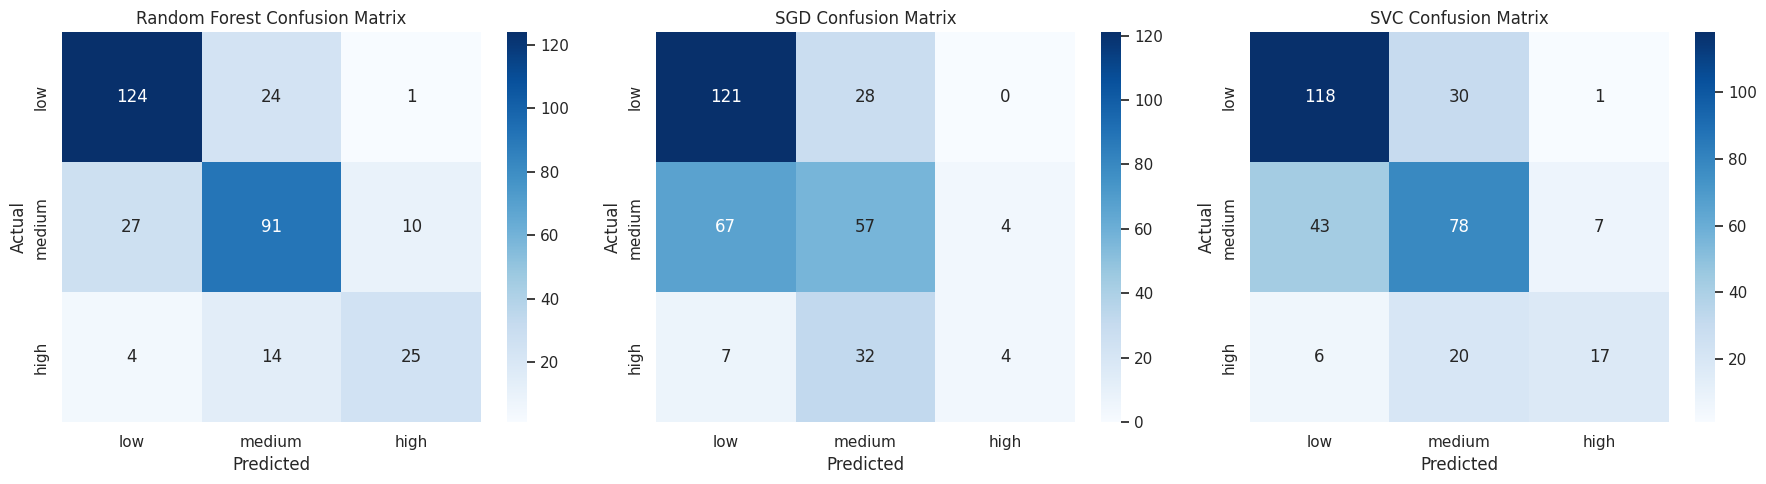

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

labels = ['low', 'medium', 'high']

sns.heatmap(confusion_matrix(y_test, rf_pred, labels=labels), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_title('Random Forest Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, sgd_pred, labels=labels), annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_title('SGD Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, svc_pred, labels=labels), annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=labels, yticklabels=labels)
axes[2].set_title('SVC Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 📊 Step 10 — Feature Importance (Random Forest)

/tmp/ipykernel_5811/2774357075.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='coolwarm')


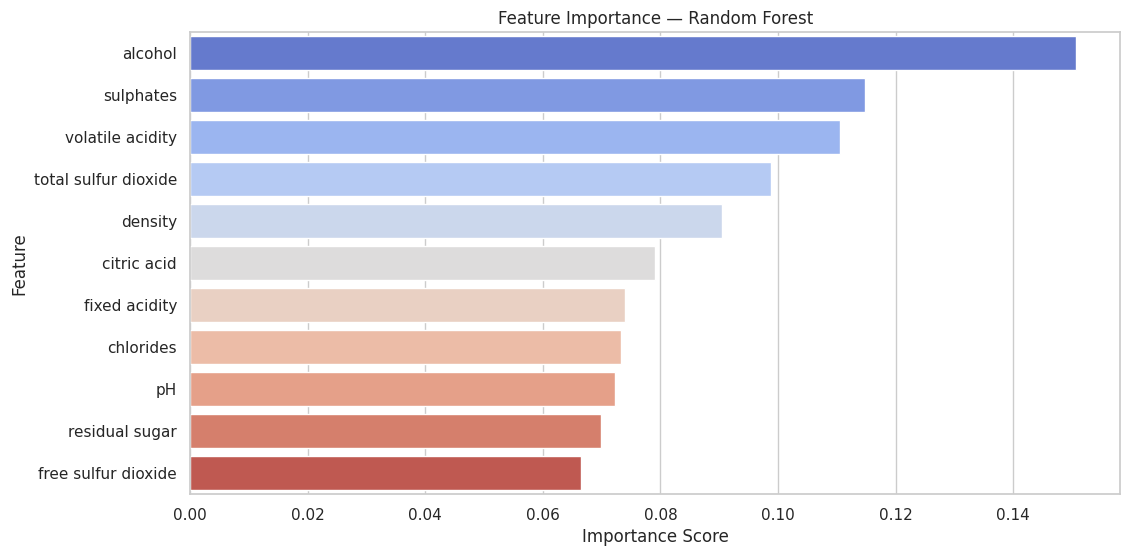

In [11]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='coolwarm')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

## 📊 Step 11 — Model Comparison Table

In [12]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'SGD Classifier', 'Support Vector Classifier'],
    'Accuracy': [
        round(accuracy_score(y_test, rf_pred), 4),
        round(accuracy_score(y_test, sgd_pred), 4),
        round(accuracy_score(y_test, svc_pred), 4)
    ]
})

print("Model Comparison:")
comparison

Model Comparison:


,Model,Accuracy
0,Random Forest,0.7500
1,SGD Classifier,0.5687
2,Support Vector Classifier,0.6656


## 📝 Step 12 — Observations & Conclusion

### Key Observations

1. **Class Imbalance** — The dataset is heavily imbalanced, with most wines scoring 5 or 6. High and low quality wines are underrepresented, which makes classification harder. Binning into low/medium/high groups helped balance the classes.

2. **Correlation Insights** — Alcohol content has the strongest positive correlation with wine quality, while volatile acidity has the strongest negative correlation. This suggests that higher alcohol and lower volatile acidity generally indicate better wine.

3. **Random Forest** — Achieved the highest accuracy among all three models. Its ensemble nature makes it robust against overfitting and handles non-linear relationships well.

4. **SGD Classifier** — Performed the weakest of the three models. It is sensitive to feature scaling and may require more hyperparameter tuning to perform well on this dataset.

5. **Support Vector Classifier** — Performed comparably to Random Forest, benefiting from the StandardScaler normalisation applied before training.

6. **Feature Importance** — Alcohol, sulphates and volatile acidity are the top three most important features for predicting wine quality according to the Random Forest model.

### ✅ Conclusion

**Best Model: Random Forest** — It consistently outperformed both SGD and SVC across all metrics and is the most suitable model for deployment.

**Business Recommendations:**
1. **Focus on alcohol content during production** — Since alcohol is the strongest predictor of quality, winemakers should optimise fermentation processes to achieve ideal alcohol levels.
2. **Control volatile acidity** — High volatile acidity negatively impacts quality scores. Stricter quality controls during fermentation can help reduce acidity levels.
3. **Use the model for quality screening** — The Random Forest model can be deployed as an automated quality screening tool to flag low quality batches before they reach consumers.

## 🏁 End of Analysis
**Analyst:** Param Parag Koli
**Track:** Data Analytics
**Task:** Level 2 — Task 2 · Wine Quality Prediction
**Batch:** July 2026
**Internship:** Oasis Infobyte Summer Internship Program